# Notebook 06 - Analyse de la vitesse et de la direction

Nous avons pour objectif d'analyser le mouvement de la voiture ? partir de la trajectoire estim?e.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import pandas as pd
import matplotlib.pyplot as plt

from src.trajectory import load_trajectory_csv
from src.analysis import compute_motion_analysis, save_motion_analysis_csv
from src.visualization import plot_speed, plot_direction

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Chargement de la trajectoire

Nous chargeons `results/trajectory_estimated.csv`, qui contient les centres estim?s par Lucas-Kanade.

In [2]:
trajectory_df = load_trajectory_csv(RESULTS_DIR / "trajectory_estimated.csv")
trajectory_df.head()

,frame_id,center_x,center_y,nb_points
0,0,627.000000,350.500000,60
1,1,621.393921,339.999298,38
2,2,617.734863,337.203674,37
3,3,616.477600,337.255096,37
4,4,615.217590,337.044220,37


## Calculs de mouvement

Nous calculons `dx = x(t+1)-x(t)`, `dy = y(t+1)-y(t)`, la distance, la vitesse apparente en pixels/frame et la direction avec `atan2`. La vitesse n'est pas en m/s car nous n'avons pas de calibration m?trique ni de fr?quence temporelle physique.

In [3]:
motion_df = compute_motion_analysis(trajectory_df)
save_motion_analysis_csv(motion_df, RESULTS_DIR / "motion_analysis_estimated.csv")
motion_df.head()

,frame_id,center_x,center_y,dx,dy,distance,speed_px_frame,direction_rad,direction_deg,interpretation
0,0,627.000000,350.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,mouvement quasi nul
1,1,621.393921,339.999298,-5.606079,-10.500702,11.903481,11.903481,-2.061177,-118.096716,mouvement vers le haut
2,2,617.734863,337.203674,-3.659058,-2.795624,4.604803,4.604803,-2.489174,-142.619147,mouvement diagonal
3,3,616.477600,337.255096,-1.257263,0.051422,1.258314,1.258314,3.100715,177.657905,mouvement vers la gauche
4,4,615.217590,337.044220,-1.260010,-0.210876,1.277534,1.277534,-2.975769,-170.498976,mouvement vers la gauche


Nous observons les premi?res lignes du tableau. La premi?re ligne a un d?placement nul car elle sert de r?f?rence initiale.

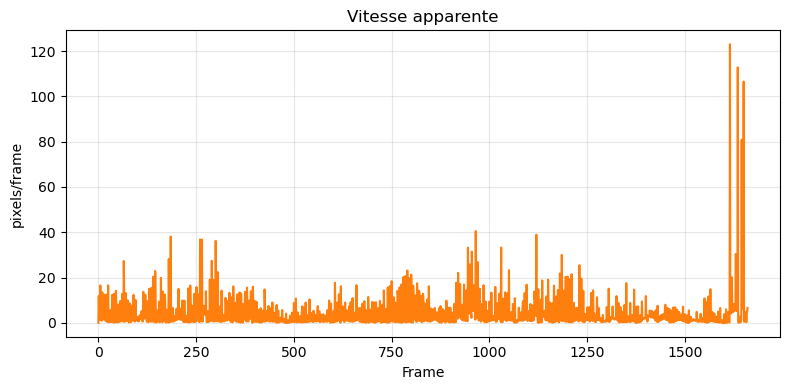

In [4]:
fig = plot_speed(motion_df, save_path=PLOTS_DIR / "speed_curve.png")
plt.show()

Nous interpr?tons les variations de vitesse comme des variations du d?placement apparent du centre entre deux frames successives.

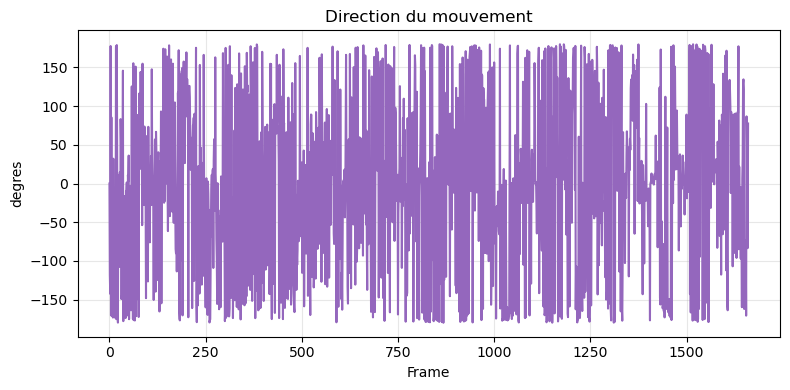

In [5]:
fig = plot_direction(motion_df, save_path=PLOTS_DIR / "direction_curve.png")
plt.show()

Nous observons la direction en degr?s. `atan2(dy, dx)` tient compte du signe de `dx` et de `dy`, ce qui permet de distinguer les directions du mouvement dans l'image.